# Random Cube Visualizer (1995) with Official LULC Classes

This notebook picks a random cube from `../data/dataset/1995`, prints all metadata, and visualizes imagery/mask using the Decadal LULC India class legend.

Class sources used in `src/lulc_classes.py`:
- ORNL DAAC Decadal LULC India guide
- Remote Sensing (2015) 7(3):2401-2430

In [22]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display

from lulc_classes import LULC_CLASS_MAP

plt.style.use('seaborn-v0_8-whitegrid')

selected_cube = Path('../data/dataset/2005/cube_5.npz')

if not selected_cube.exists():
    raise FileNotFoundError(f'Cube not found at: {selected_cube.resolve()}')

print(f'Selected cube: {selected_cube.name}')


# Now you can load it directly
# cube = np.load(selected_cube)

Selected cube: cube_5.npz


In [15]:
# Point to the directory, not a specific file
DATA_DIR = Path('../data/dataset/2005')

cube_files = sorted(DATA_DIR.glob('*.npz'))

print(f'Cube directory: {DATA_DIR.resolve()}')
print(f'Found {len(cube_files)} cubes')

if not cube_files:
    raise FileNotFoundError(f'No .npz cubes found in {DATA_DIR.resolve()}')

selected_cube = random.choice(cube_files)
print(f'Selected cube: {selected_cube.name}')

Cube directory: /Users/neerajkaroshi/Desktop/Projects/clay_LULC/data/dataset/2005
Found 353 cubes
Selected cube: cube_309.npz


In [23]:
cube = np.load(selected_cube)

print('Keys in cube:', list(cube.files))

rows = []
for key in cube.files:
    value = cube[key]
    rows.append({
        'key': key,
        'shape': value.shape,
        'dtype': str(value.dtype),
        'min': float(np.nanmin(value)) if value.size else None,
        'max': float(np.nanmax(value)) if value.size else None
    })

meta_df = pd.DataFrame(rows)
display(meta_df)

image = cube['image']
mask = cube['mask']
latlon = cube['latlon']
year = int(cube['year'])

def decode_scalar_pair(pair):
    # pair = [sin(2*pi*x), cos(2*pi*x)]
    angle = np.arctan2(pair[0], pair[1])
    return (angle / (2 * np.pi)) % 1.0

lat_norm = decode_scalar_pair(latlon[:2])
lon_norm = decode_scalar_pair(latlon[2:])
lat_est = lat_norm * 180.0 - 90.0
lon_est = lon_norm * 360.0 - 180.0

print(f'Year: {year}')
print(f'Encoded latlon vector: {latlon}')
print(f'Approx decoded latitude:  {lat_est:.6f}')
print(f'Approx decoded longitude: {lon_est:.6f}')

Keys in cube: ['image', 'mask', 'latlon', 'year']


,key,shape,dtype,min,max
0,image,"(4, 256, 256)",float32,7701.000000,63514.000000
1,mask,"(256, 256)",uint8,6.000000,6.000000
2,latlon,"(4,)",float32,-0.981999,-0.188885
3,year,(),int64,2005.000000,2005.000000


Year: 2005
Encoded latlon vector: [-0.8887572  -0.45837823 -0.9819993  -0.18888475]
Approx decoded latitude:  31.358757
Approx decoded longitude: 79.112305


In [24]:
classes, counts = np.unique(mask, return_counts=True)
class_rows = []
for class_id, pixel_count in zip(classes, counts):
    level_1, level_2 = LULC_CLASS_MAP.get(int(class_id), ('Unknown', 'Unknown'))
    class_rows.append({
        'class_id': int(class_id),
        'level_1': level_1,
        'level_2': level_2,
        'pixel_count': int(pixel_count),
        'percent': 100.0 * float(pixel_count) / mask.size
    })

class_df = pd.DataFrame(class_rows).sort_values('pixel_count', ascending=False).reset_index(drop=True)
display(class_df)

legend_df = pd.DataFrame([
    {'class_id': class_id, 'level_1': lvl1, 'level_2': lvl2}
    for class_id, (lvl1, lvl2) in sorted(LULC_CLASS_MAP.items())
])
display(legend_df)

,class_id,level_1,level_2,pixel_count,percent
0,6,Forest,Evergreen Broadleaf Forest,65536,100.0


,class_id,level_1,level_2
0,0,No Data,No Data
1,1,Built-up Land,Built-up Land
2,2,Agricultural Land,Crop land
3,3,Agricultural Land,Fallow land
4,4,Forest,Deciduous Broadleaf Forest
5,5,Forest,Deciduous Needleleaf Forest
6,6,Forest,Evergreen Broadleaf Forest
7,7,Forest,Evergreen Needleleaf Forest
8,8,Forest,Mixed Forest
9,9,Barren Land,Barren rocky


## Index Interpretation Guide

- **NDVI** `(NIR-Red)/(NIR+Red)`: vegetation vigor/greenness. High values usually indicate healthy dense vegetation.
- **NDWI** `(Green-NIR)/(Green+NIR)`: surface water/wetness indicator. Higher values usually indicate water or wet surfaces.
- **GNDVI** `(NIR-Green)/(NIR+Green)`: chlorophyll-focused vegetation index, useful for crop/canopy status.
- **SAVI** `1.5*(NIR-Red)/(NIR+Red+0.5)`: vegetation index adjusted to reduce soil-background influence in sparse cover.

Quick reading rule: values closer to **+1** generally indicate stronger target signal (vegetation/water, depending on index), values near **0** are mixed/neutral, and negatives often indicate non-target surfaces (e.g., bare/built, shadow, clouds, or deep water depending on index).


,index,min,max,mean,std
0,NDVI,-0.194913,0.468450,0.038537,0.035196
1,NDWI,-0.470238,0.130519,-0.090481,0.053386
2,GNDVI,-0.130519,0.470238,0.090481,0.053386
3,SAVI,-0.292368,0.702669,0.057804,0.052793


,index,threshold,positive_pixels,positive_percent
0,NDVI,0.3,213,0.325012
1,NDWI,0.1,2,0.003052
2,GNDVI,0.2,474,0.723267
3,SAVI,0.2,224,0.341797


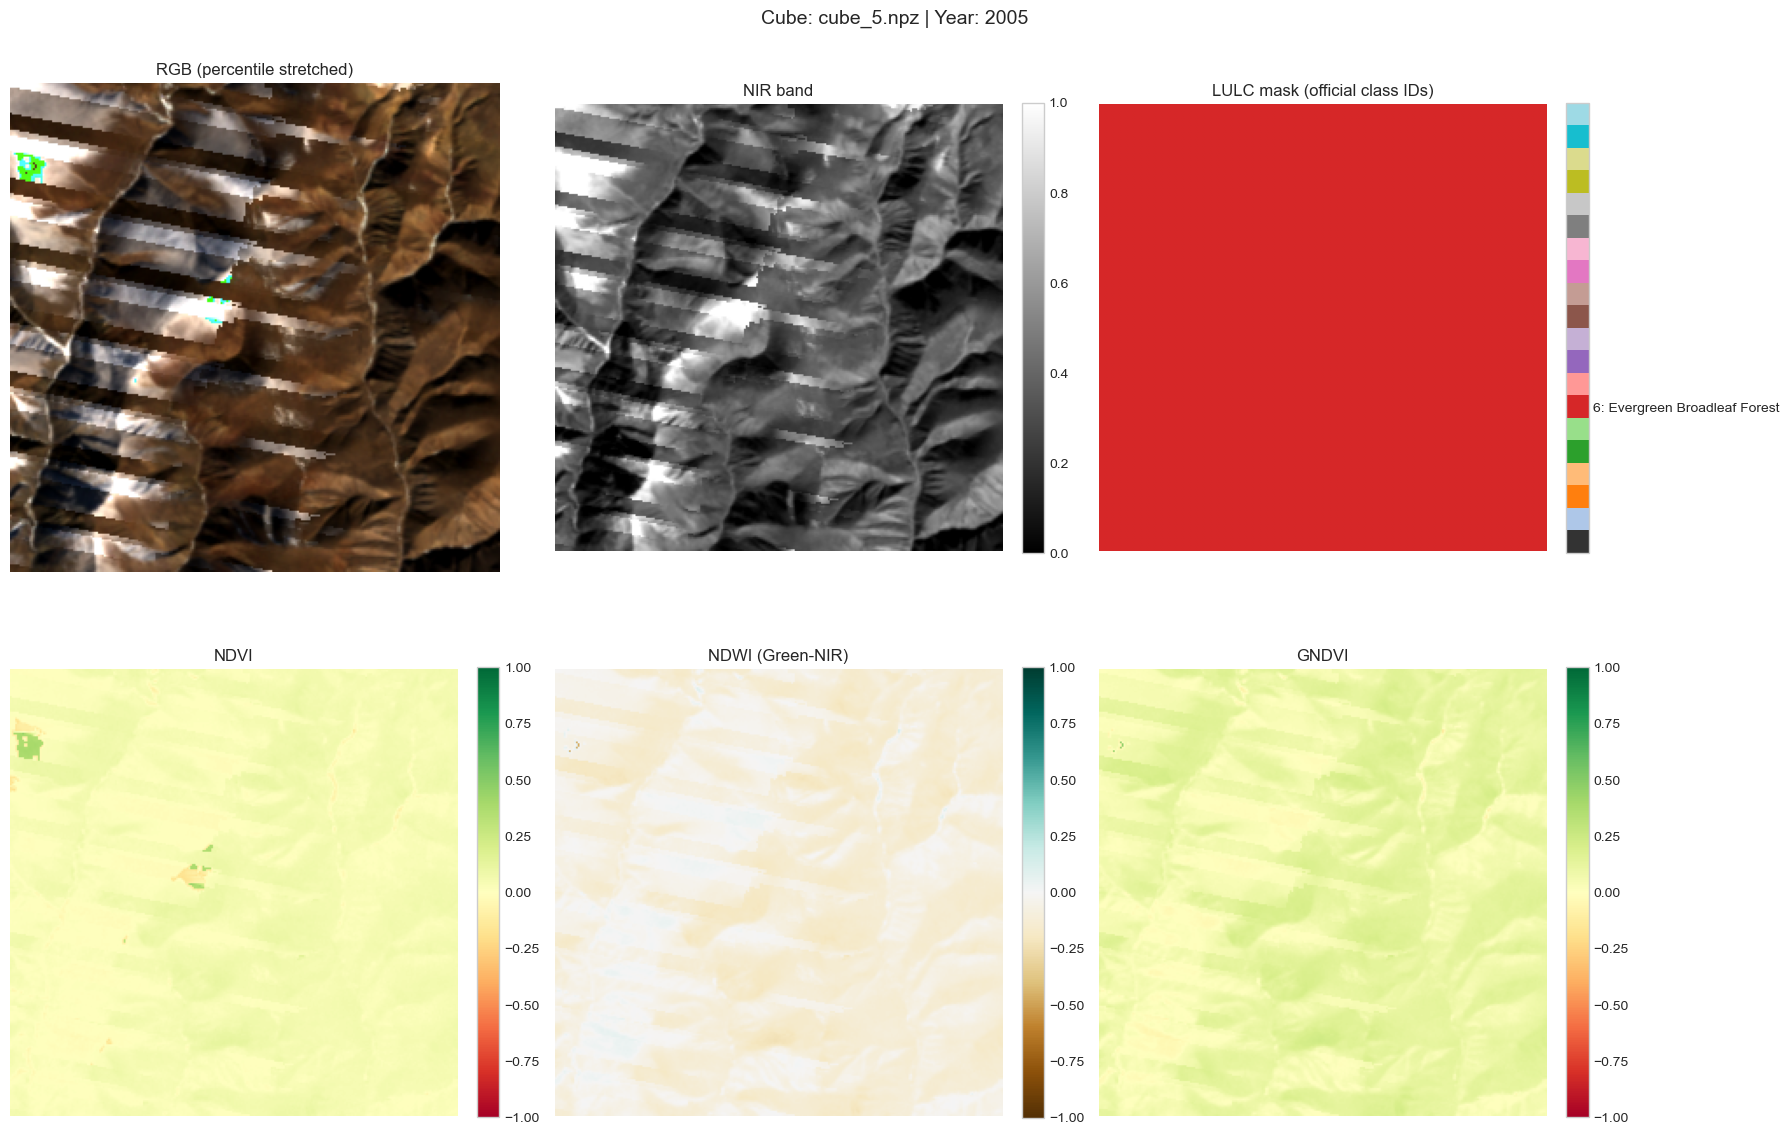

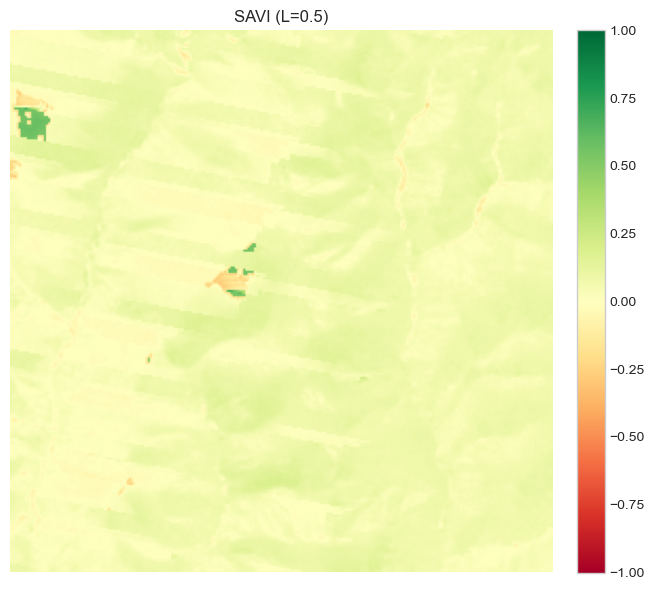

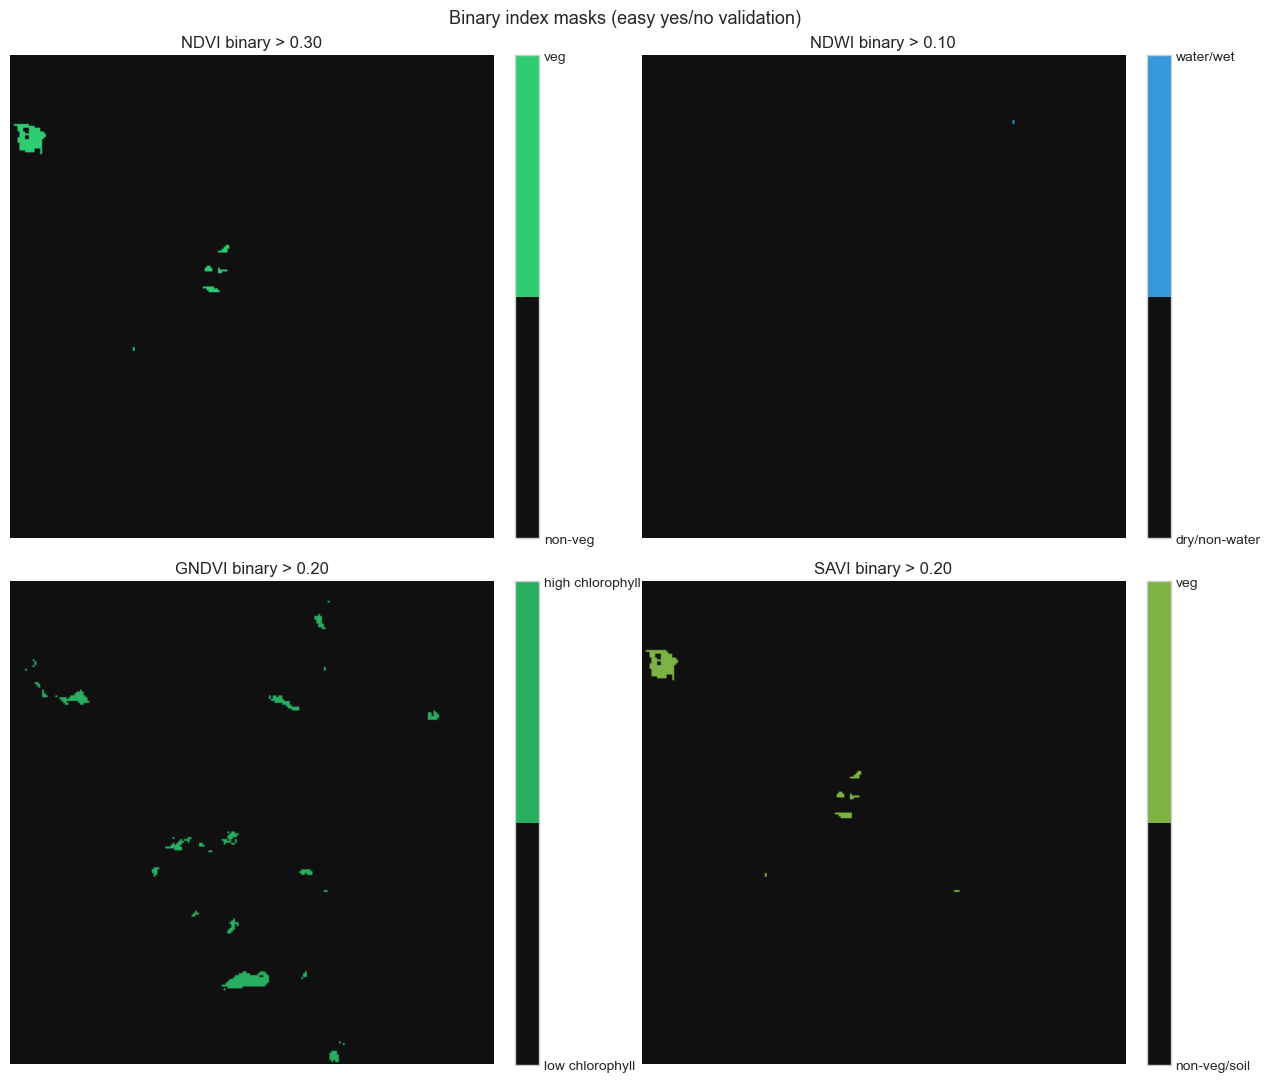

In [25]:
def percentile_stretch(arr, pmin=2, pmax=98):
    arr = arr.astype(np.float32)
    lo, hi = np.nanpercentile(arr, [pmin, pmax])
    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)
    out = (arr - lo) / (hi - lo)
    return np.clip(out, 0, 1)

red, green, blue, nir = image[0], image[1], image[2], image[3]
rgb = np.dstack([red, green, blue])
rgb_vis = percentile_stretch(rgb)
nir_vis = percentile_stretch(nir)

eps = 1e-6

# NDVI: vegetation vigor/greenness. Higher -> healthier/denser vegetation.
ndvi = (nir - red) / (nir + red + eps)

# NDWI (Green-NIR): surface water/wetness proxy. Higher -> wetter/water-dominant pixels.
ndwi = (green - nir) / (green + nir + eps)

# GNDVI: chlorophyll-sensitive vegetation signal using green instead of red.
gndvi = (nir - green) / (nir + green + eps)

# SAVI: NDVI variant with soil adjustment (L=0.5) for sparse vegetation/background soil.
savi = 1.5 * (nir - red) / (nir + red + 0.5 + eps)

index_map = {
    'NDVI': ndvi,
    'NDWI': ndwi,
    'GNDVI': gndvi,
    'SAVI': savi,
}

index_stats = []
for name, arr in index_map.items():
    index_stats.append({
        'index': name,
        'min': float(np.nanmin(arr)),
        'max': float(np.nanmax(arr)),
        'mean': float(np.nanmean(arr)),
        'std': float(np.nanstd(arr)),
    })
index_stats_df = pd.DataFrame(index_stats)
display(index_stats_df)

# Binary thresholds for quick presence/absence validation.
# Tune these if your study area or season needs different cutoffs.
thresholds = {
    'NDVI': 0.30,   # vegetation presence
    'NDWI': 0.10,   # water/wetness presence
    'GNDVI': 0.20,  # vegetation/chlorophyll presence
    'SAVI': 0.20,   # vegetation presence with soil adjustment
}

binary_masks = {name: (arr > thresholds[name]).astype(np.uint8) for name, arr in index_map.items()}

binary_colors = {
    'NDVI': ['#101010', '#2ecc71'],
    'NDWI': ['#101010', '#3498db'],
    'GNDVI': ['#101010', '#27ae60'],
    'SAVI': ['#101010', '#7cb342'],
}

binary_labels = {
    'NDVI': ('non-veg', 'veg'),
    'NDWI': ('dry/non-water', 'water/wet'),
    'GNDVI': ('low chlorophyll', 'high chlorophyll'),
    'SAVI': ('non-veg/soil', 'veg'),
}

binary_stats = []
for name, bm in binary_masks.items():
    pos = int(np.sum(bm == 1))
    total = int(bm.size)
    binary_stats.append({
        'index': name,
        'threshold': thresholds[name],
        'positive_pixels': pos,
        'positive_percent': 100.0 * pos / total,
    })
binary_stats_df = pd.DataFrame(binary_stats)
display(binary_stats_df)

base_colors = plt.cm.tab20(np.linspace(0, 1, 20))
base_colors[0] = np.array([0.2, 0.2, 0.2, 1.0])  # class 0 = no data
mask_cmap = ListedColormap(base_colors)
mask_norm = BoundaryNorm(np.arange(-0.5, 20.5, 1), mask_cmap.N)
present_ids = sorted(int(v) for v in np.unique(mask))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(rgb_vis)
axes[0, 0].set_title('RGB (percentile stretched)')
axes[0, 0].axis('off')

im1 = axes[0, 1].imshow(nir_vis, cmap='gray')
axes[0, 1].set_title('NIR band')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(mask, cmap=mask_cmap, norm=mask_norm)
axes[0, 2].set_title('LULC mask (official class IDs)')
axes[0, 2].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04, ticks=present_ids)
cbar2.ax.set_yticklabels([f"{cid}: {LULC_CLASS_MAP.get(cid, ('Unknown', 'Unknown'))[1]}" for cid in present_ids])

im3 = axes[1, 0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1, 0].set_title('NDVI')
axes[1, 0].axis('off')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(ndwi, cmap='BrBG', vmin=-1, vmax=1)
axes[1, 1].set_title('NDWI (Green-NIR)')
axes[1, 1].axis('off')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(gndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1, 2].set_title('GNDVI')
axes[1, 2].axis('off')
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.suptitle(f'Cube: {selected_cube.name} | Year: {year}', fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
im6 = ax.imshow(np.clip(savi, -1, 1), cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('SAVI (L=0.5)')
ax.axis('off')
plt.colorbar(im6, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Binary maps: 1 means "target present" for each index.
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, name in zip(axes.flat, ['NDVI', 'NDWI', 'GNDVI', 'SAVI']):
    cmap = ListedColormap(binary_colors[name])
    im = ax.imshow(binary_masks[name], cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f"{name} binary > {thresholds[name]:.2f}")
    ax.axis('off')

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cbar.ax.set_yticklabels(list(binary_labels[name]))

plt.suptitle('Binary index masks (easy yes/no validation)', fontsize=13)
plt.tight_layout()
plt.show()



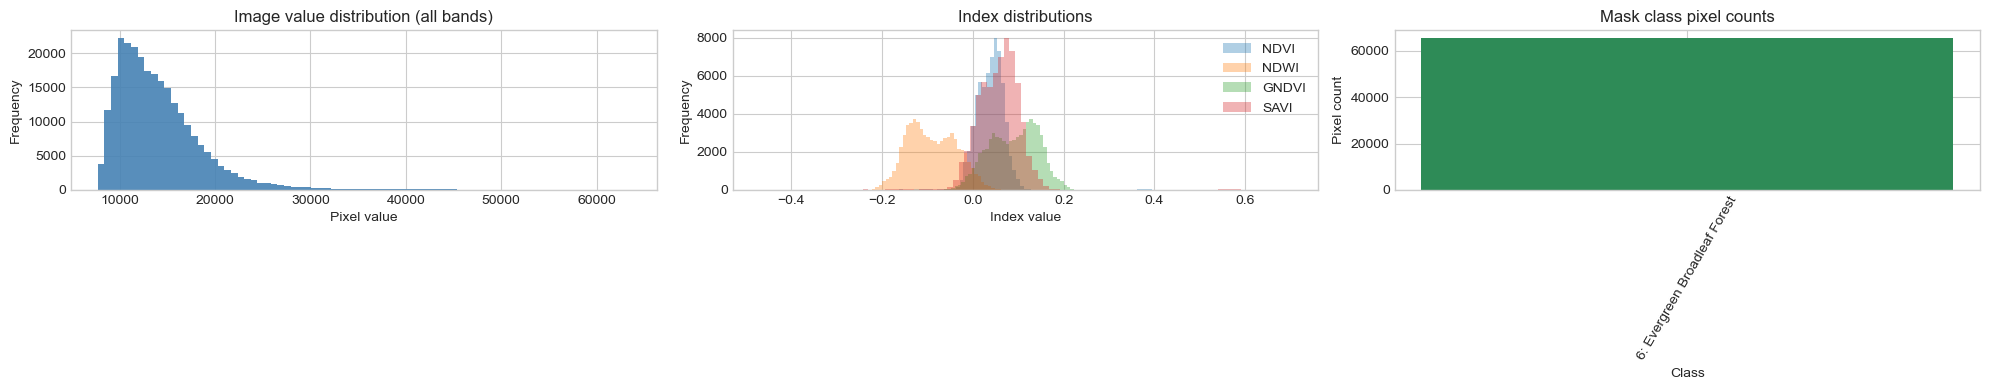

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

axes[0].hist(image.reshape(-1), bins=80, color='steelblue', alpha=0.9)
axes[0].set_title('Image value distribution (all bands)')
axes[0].set_xlabel('Pixel value')
axes[0].set_ylabel('Frequency')

for name, arr in index_map.items():
    axes[1].hist(arr.reshape(-1), bins=80, alpha=0.35, label=name)
axes[1].set_title('Index distributions')
axes[1].set_xlabel('Index value')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plot_df = class_df.copy()
plot_df['class_label'] = plot_df['class_id'].astype(str) + ': ' + plot_df['level_2']
axes[2].bar(plot_df['class_label'], plot_df['pixel_count'], color='seagreen')
axes[2].set_title('Mask class pixel counts')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Pixel count')
axes[2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()



Publication-style figure saved as: visual_validation_cube_5.npz_2005.png


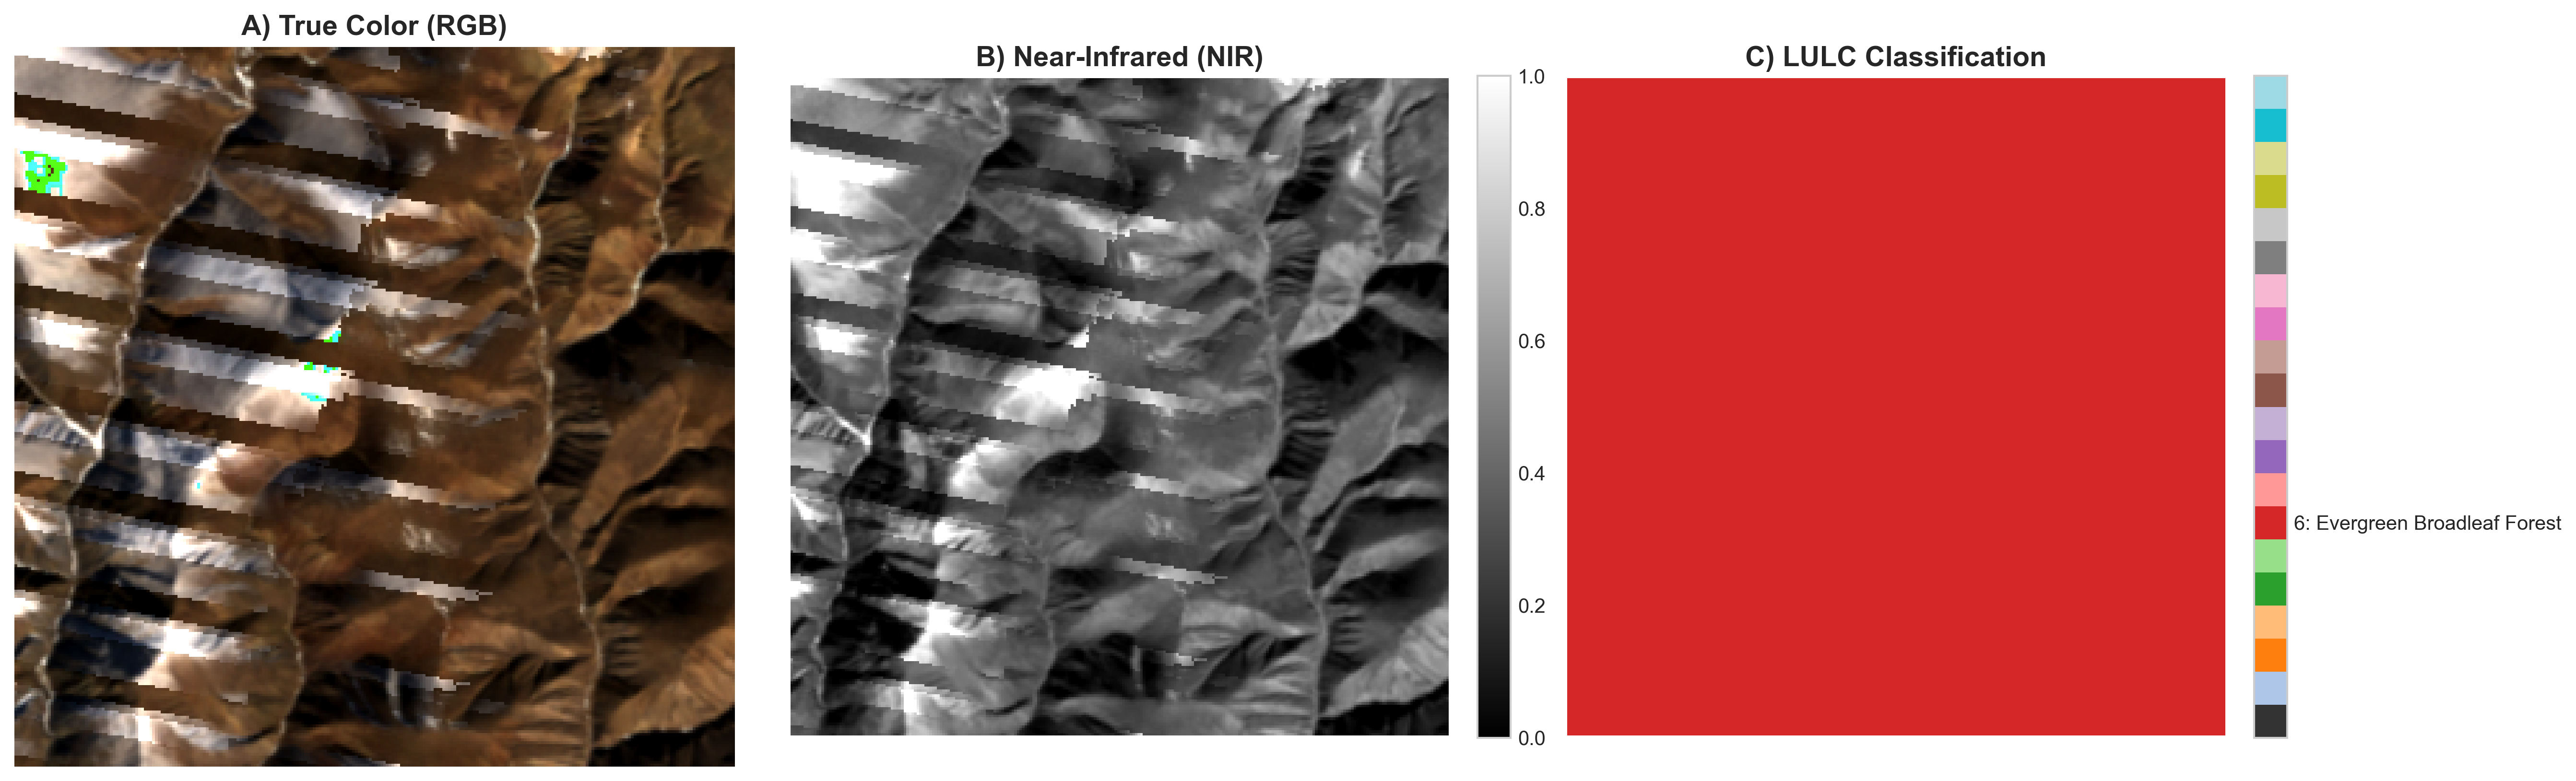

In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1. Prepare Data for Viz
# RGB is bands [0, 1, 2], NIR is band [3]
red, green, blue, nir = image[0], image[1], image[2], image[3]
rgb = np.dstack([red, green, blue])

# Apply stretches
rgb_vis = percentile_stretch(rgb)
# Standardize NIR stretch for consistency
nir_vis = percentile_stretch(nir)

# 2. Setup Publication-Style Colormap for LULC
# Assuming LULC_CLASS_MAP is defined as {id: (hex, name)} 
# or use your existing base_colors logic
present_ids = sorted(int(v) for v in np.unique(mask) if v > 0)
mask_cmap = ListedColormap(base_colors)
mask_norm = BoundaryNorm(np.arange(-0.5, 20.5, 1), mask_cmap.N)

# 3. Create the Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

# Panel A: RGB
axes[0].imshow(rgb_vis)
axes[0].set_title('A) True Color (RGB)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Panel B: NIR
im_nir = axes[1].imshow(nir_vis, cmap='gray')
axes[1].set_title('B) Near-Infrared (NIR)', fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im_nir, ax=axes[1], fraction=0.046, pad=0.04)

# Panel C: LULC Mask
im_mask = axes[2].imshow(mask, cmap=mask_cmap, norm=mask_norm)
axes[2].set_title('C) LULC Classification', fontsize=14, fontweight='bold')
axes[2].axis('off')

# Specific Legend for LULC
cbar = plt.colorbar(im_mask, ax=axes[2], fraction=0.046, pad=0.04, ticks=present_ids)
# Using the second element of the tuple in LULC_CLASS_MAP as the label
cbar.ax.set_yticklabels([f"{cid}: {LULC_CLASS_MAP.get(cid, ('#000', 'Unknown'))[1]}" for cid in present_ids])

# 4. Final Formatting
plt.tight_layout()

# Save for publication
output_filename = f"visual_validation_{selected_cube.name}_{year}.png"
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
print(f"Publication-style figure saved as: {output_filename}")

plt.show()